# Проект: удержание клиентов сети фитнес-центров

# Описание проекта
Сеть фитнес-центров «Культурист-датасаентист» разрабатывает стратегию взаимодействия с клиентами на основе аналитических данных. 
Распространённая проблема фитнес-клубов и других сервисов — отток клиентов. Как понять, что клиент больше не с вами? Можно записать в отток тех, кто попросил закрыть договор или удалил аккаунт. Однако клиенты не всегда уходят демонстративно: чаще перестают пользоваться сервисом тихо. 
Индикаторы оттока зависят от специфики отрасли. Когда пользователь редко, но стабильно закупается в интернет-магазине — не похоже, что он «отвалился». А вот если две недели не заходит на канал с ежедневно обновляемым контентом, дела плохи: подписчик заскучал и, кажется, оставил вас. 
Для фитнес-центра можно считать, что клиент попал в отток, если за последний месяц ни разу не посетил спортзал. Конечно, не исключено, что он уехал на Бали и по приезде обязательно продолжит ходить на фитнес. Однако чаще бывает наоборот. Если клиент начал новую жизнь с понедельника, немного походил в спортзал, а потом пропал — скорее всего, он не вернётся. 
Чтобы бороться с оттоком, отдел по работе с клиентами «Культуриста-датасаентиста» перевёл в электронный вид множество клиентских анкет. Задача — провести анализ и подготовить план действий по удержанию клиентов.  

# Цели проекта
- Научиться прогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;
- Сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;
- Проанализировать основные признаки, наиболее сильно влияющие на отток;
- Сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:
- Выделить целевые группы клиентов;
- Предложить меры по снижению оттока;
- Определить другие особенности взаимодействия с клиентами.

# Документация
Заказчик предоставил сведения в csv-файлах. Заказчик подготовил данные, которые содержат данные на месяц до оттока и факт оттока на определённый месяц. Набор данных включает следующие поля:
1. Данные клиента за предыдущий до проверки факта оттока месяц:
- 'gender' — пол;
- 'Near_Location' — проживание или работа в районе, где находится фитнес-центр;
- 'Partner' — сотрудник компании-партнёра клуба (сотрудничество с компаниями, чьи сотрудники могут получать скидки на абонементв таком случае фитнес-центр хранит информацию о работодателе клиента);
- Promo_friends — факт первоначальной записи в рамках акции «приведи друга» (использовал промо-код от знакомого при оплате первого абонемента);
- 'Phone' — наличие контактного телефона;
- 'Age' — возраст;
- 'Lifetime' — время с момента первого обращения в фитнес-центр (в месяцах).
2. Информация на основе журнала посещений, покупок и информация о текущем статусе абонемента клиента:
- 'Contract_period' — длительность текущего действующего абонемента (месяц, 6 месяцев, год);
- 'Month_to_end_contract' — срок до окончания текущего действующего абонемента (в месяцах);
- 'Group_visits' — факт посещения групповых занятий;
- 'Avg_class_frequency_total' — средняя частота посещений в неделю за все время с начала действия абонемента;
- 'Avg_class_frequency_current_month' — средняя частота посещений в неделю за предыдущий месяц;
- 'Avg_additional_charges_total' — суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон.
- 'Churn' — факт оттока в текущем месяце.
3. Путь к файлу: /datasets/gym_churn.csv

# План исследования
1. Загрузка данных/разведовательный анализ 
2. Исследовательский анализ 
3. Построение модели прогнозирования 
4. Кластеризация клиентов 
5. Общий вывод и рекомендации

# Загрузка данных и разведовательный анализ

In [98]:
import pandas as pd
import seaborn as sns; sns.set()
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # импорт необходимых инструментов

In [99]:
gym_data = pd.read_csv("/datasets/gym_churn.csv") # создание фрейма
gym_data.head() # просмотр головы фрейма

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [100]:
gym_data.describe() # просмотр основной информации о фрейме

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [101]:
gym_data.info() # просмотр основной информации о фрейме

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

- Gender:представлен 2-мя уникальными значениями 0 и 1, примерко в равном количестве
- Near_Location: представлен 2-мя уникальными значениями 0 и 1. Большинство клиентов (85%) находятся в близи к фитнес-центру
- Partner: представлен 2-мя уникальными значениями 0 и 1. Примерно половина клиентов пришла по партнерской программе.
- Promo_friends: представлен 2-мя уникальными значениями 0 и 1. Примерно 30% клиентов возпользовались программой Promo_friends.
- Phone: представлен 2-мя уникальными значениями 0 и 1. Большинство клиентов (90%) предоставили телефон для связи.
- Contract_period: Средний срок контракта составляет около 4.68 лет.
- Group_visits: Не все клиенты (41%) посещает групповые занятия.
- Age: Средний возраст клиентов составляет около 29 лет.
- Avg_additional_charges_total: Средние дополнительные сборы составляют около 146.94
- Month_to_end_contract: Средний оставшийся срок контракта составляет около 4.32 месяца.
- Lifetime: Средний период жизни клиента составляет около 3.72 года.
- Avg_class_frequency_total: Средняя частота посещения составляет около 1.88 раза.
- Avg_class_frequency_current_month: Средняя частота посещения в текущем месяце составляет около 1.77 раза.
- Churn: представлен 2-мя уникальными значениями 0 и 1. Примерно треть клиентов (27%) покинула компанию.

В данных не наблюдается аномальных значений выбросов.

Разведочный анализ завершён, можно переходить к предобработке.

# Предобработка

In [102]:
gym_data["Contract_period"].value_counts() # просмтоnр уникальных значений

1     2207
12     960
6      833
Name: Contract_period, dtype: int64

Месячные контракты превалируют над прочими. Следующим шагом для удобства дальнейшей работы приведём названия полей к нижнему регистру 

In [103]:
gym_data.columns = gym_data.columns.str.lower() # перевод в нижний регистр 
gym_data.head() # просмотр результата

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


Поля приведены к нижнему регистру. В следуюших шагах переведём некоторые поля к типу bool а другие к int64

In [104]:
gym_data[["gender", "near_location", "partner", "promo_friends", "phone", "group_visits", "churn"]] = gym_data[
["gender", "near_location", "partner", "promo_friends", "phone", "group_visits", "churn"]].astype(bool) # приведение к bool

In [105]:
gym_data[["month_to_end_contract"]] = gym_data[["month_to_end_contract"]].astype("int64") # приведение к инт

In [106]:
gym_data.info() # проверка результьтата 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   bool   
 1   near_location                      4000 non-null   bool   
 2   partner                            4000 non-null   bool   
 3   promo_friends                      4000 non-null   bool   
 4   phone                              4000 non-null   bool   
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   bool   
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   int64  
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

В следующем шаге рассмотрим группы тех кто ушёл и кто остался, переходим к EDA


# Исследовательский анализ 

In [107]:
mean_gym = gym_data.groupby("churn").mean() # просмотр средних значений
mean_gym

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
churn,,,,,,,,,,,,,
False,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
True,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Построим столбчатые гистограммы, посмотрим на рапределение 

In [108]:
le = LabelEncoder() # для этой задачи воспользуемся LabelEncoder

gym_data["churn"] = le.fit_transform(gym_data["churn"]) # перевод категориальных значений в числовые
churned = gym_data[gym_data["churn"] == 1] # клиент покинул компанию
stayed = gym_data[gym_data["churn"] == 0]  # клиент остался 

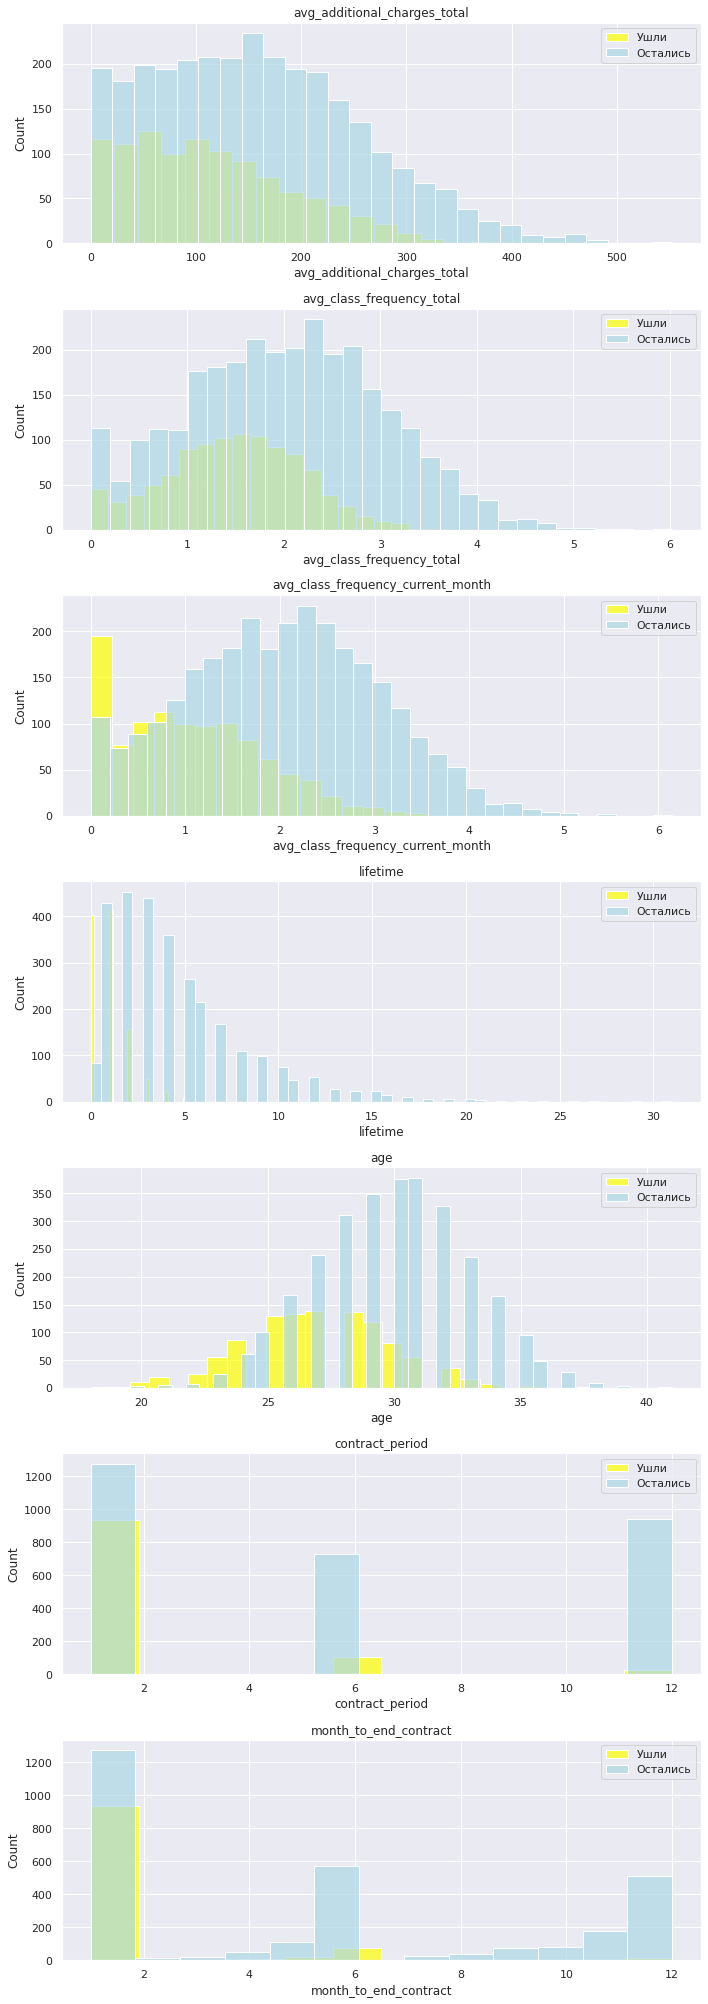

In [109]:
hist_columns = ["avg_additional_charges_total", "avg_class_frequency_total", "avg_class_frequency_current_month", "lifetime", "age", "contract_period", "month_to_end_contract"]

fig, axes = plt.subplots(len(hist_columns), 1, figsize=(10, 4 * len(hist_columns))) # Проектирование фигуры

for i, column in enumerate(hist_columns): 
    sns.histplot(churned[column], ax = axes[i], label = "Ушли", color = "yellow" , alpha = 0.7) # проектирование для ушедших
    sns.histplot(stayed[column], ax = axes[i], label = "Остались", color = "lightblue", alpha = 0.7) # проектирование для оставшихся
    
    axes[i].set_title(column) # отображение легенды
    axes[i].legend(loc = "upper right")
    
plt.tight_layout() # отображение графика
plt.show()

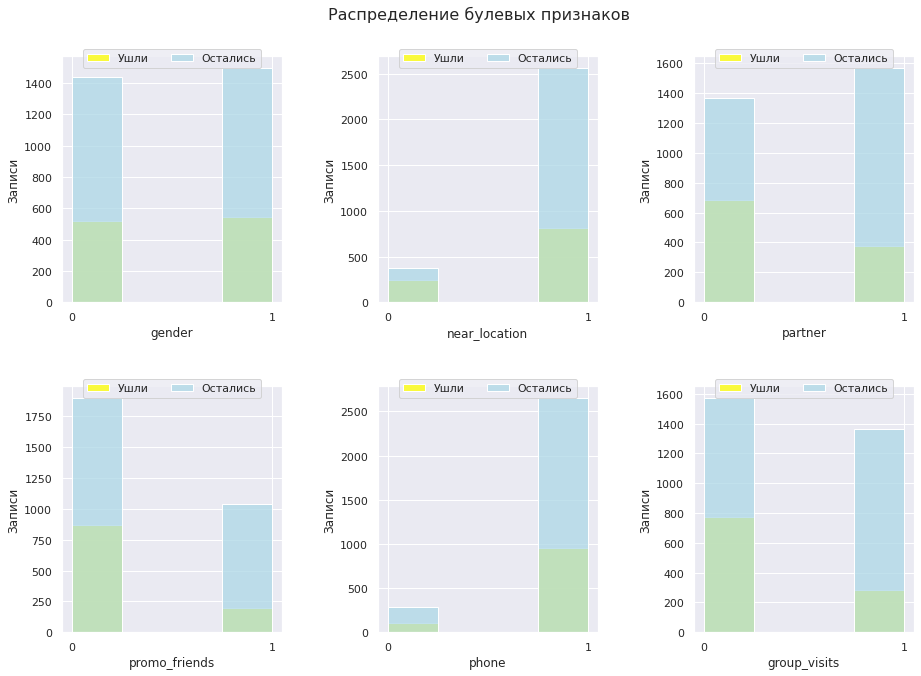

In [110]:
boolF = gym_data.select_dtypes(include = [bool]).columns.tolist() # список булевых признаков

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (14, 10)) # проектирование осей
fig.tight_layout(pad = 5.0)
fig.suptitle("Распределение булевых признаков", fontsize = 16)

for ax, feature in zip(axes.flat, boolF):
    sns.histplot(gym_data.query("churn == 1")[feature].astype(int), bins = 4, ax = ax, kde = False, color = "yellow", label = "Ушли") # гистограмма для ушедших
    
    sns.histplot(gym_data.query("churn == 0")[feature].astype(int), bins = 4, ax = ax, kde = False, color ="lightblue", label = "Остались") # гистограмма для оставшихся
    
    ax.set_xticks([0, 1]) # подграфик
    ax.set_xlabel(feature, fontsize = 12)
    ax.set_ylabel("Записи", fontsize = 12)
    
    ax.legend(loc = 'upper center', bbox_to_anchor=(0.5, 1.05), ncol=2) # настройка легенды для кождого подграфика 

plt.show() # отображение 

- Пол: средние значения одинаковы, уходят равное число мужчин и женщин.
- Близость к месту работы или проживания снижает риск ухода.
- Клиенты партнерских компаний реже уходят.
- Участники акции "Приведи друга" в 2 раза реже покидают клуб.
- Контактный телефон оставляют в равной степени и те, и другие.
- Длительный абонемент связан с меньшим уходом.
- Оставшиеся чаще посещают групповые занятия — почти в 2 раза.
- Средний возраст ушедших — 27 лет, оставшихся — 30 лет.
- Ушедшие тратили на допуслуги 115, оставшиеся — 158.
- У оставшихся в среднем более 5 месяцев до окончания контракта, у ушедших — около полутора месяцев.
- Лайфтам ушедших — около месяца; те, кто посещает более 5 месяцев, остаются.
- Оставшиеся чаще посещали центр за месяц до ухода — в 2 раза чаще, чем ушедшие.

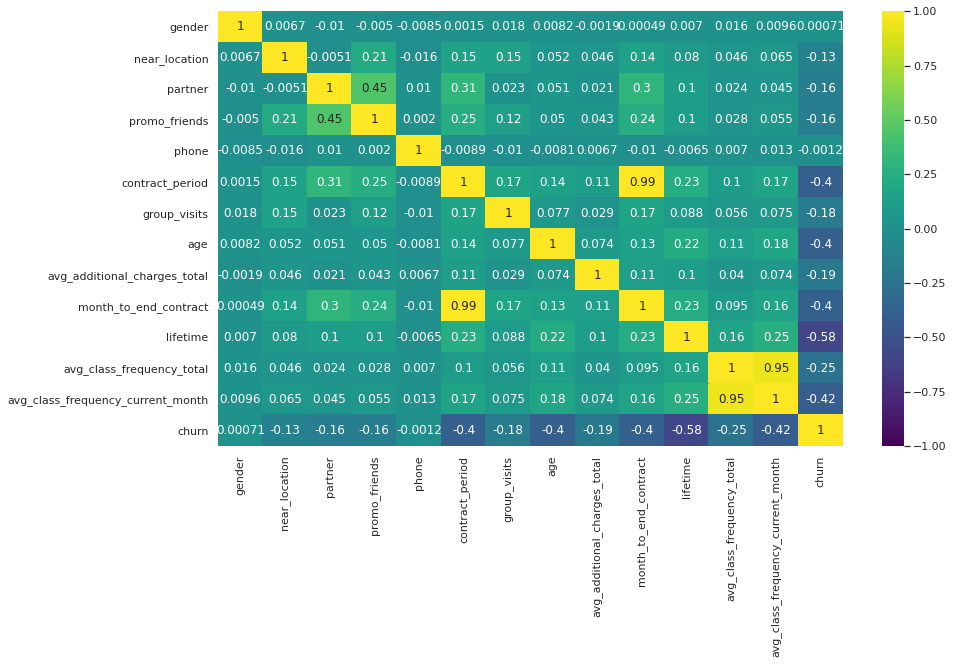

In [111]:
corr = gym_data.corr(method = "spearman") # воспользуемся методом Спирмена

plt.figure(figsize=(14, 8)) # проектирование фигуры
sns.heatmap(corr, annot = True, cmap = 'viridis', vmin = -1, vmax = 1, center = 0) # проекктирование матрицы
plt.show() # отображение 

На карте видно отрицательную корреляцию между 'churn' и признаками — чем сильнее признак, тем ниже риск ухода. Особенно выделяются очень сильные (выше 0,95) связи:

- 'contract_period' и 'month_to_end_contract' — чем длиннее абонемент, тем больше месяцев осталось до его окончания.
- 'avg_class_frequency_current_month' и 'avg_class_frequency_total' — клиенты посещают занятия с постоянным графиком.
- Также есть корреляция 0,45 между 'partner' и 'promo_friends', что говорит о том, что участники акций чаще заключают долгосрочные контракты.

- Средний возраст клиентов — 29 лет; ушедших — 27, оставшихся — 30.
- 85% живут или работают рядом; большинство ушедших — не близко.
- Большинство приобретают абонементы на 1 месяц; ушедшие чаще выбирали короткие.
- Треть клиентов пришли по акции «Приведи друга».
- Половина — сотрудники партнера клуба, они реже уходят.
- Ушедшие реже посещали клуб и групповые занятия, а также тратили меньше на допуслуги.
- Большинство уходов происходит в последние полтора месяца действия абонемента.
- Доля оттока составляет 27%.

В следжующем шаге перейдём к прогнозированию оттока. Разделим данные на обучающуюся и валидационную выборки

In [112]:
X = gym_data.drop("churn", axis = 1)
y = gym_data ["churn"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 0) #разделение данных на признаки

Данные разделены, перейдём к стандартизцации 

In [113]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_st = scaler.fit_transform(X_train)
X_val_st = scaler.transform(X_val) # cстандартизация дланных

Стандартизация проведена, переходим к обучению модели

In [114]:
log_model = LogisticRegression(random_state = 0)
log_model.fit(X_train_st, y_train)
log_pred = log_model.predict(X_val_st)
log_prob = log_model.predict_proba(X_val_st)[:,1] # логистическая регрессия

print("Логистическая регрессия:") # вывод метрик
print("accuracy_score: {}\nprecision_score: {}\nrecall_score:{}".format(
    accuracy_score(y_val, log_pred).round(3),
    precision_score(y_val, log_pred).round(3),
    recall_score(y_val, log_pred).round(3)))

print("ROC_AUC: {:.2f}".format(roc_auc_score(y_val, log_prob))) # вывод ROC и AUC

Логистическая регрессия:
accuracy_score: 0.922
precision_score: 0.854
recall_score:0.828
ROC_AUC: 0.97


Переходим к обучению модели на тренировочной выборке случайным лесом

In [115]:
ran_mod = RandomForestClassifier(n_estimators = 100, random_state = 0) 
ran_mod.fit(X_train_st, y_train)
ran_pred = ran_mod.predict(X_val_st)
ran_prob = ran_mod.predict_proba(X_val_st)[:,1] # обучение случайного леса

print("Случайный лес:") # вывод метрик
print("accuracy_score: {}\nprecision_score: {}\nrecall_score:{}".format(
    accuracy_score(y_val, ran_pred).round(3),
    precision_score(y_val, ran_pred).round(3),
    recall_score(y_val, ran_pred).round(3)))

print("ROC_AUC: {:.2f}".format(roc_auc_score(y_val, ran_prob))) # вывод ROC AUC

Случайный лес:
accuracy_score: 0.915
precision_score: 0.839
recall_score:0.813
ROC_AUC: 0.97


Обе модели показывают высокие ROC AUC, свидетельствующие о хорошей способности различать классы. Логистическая регрессия превосходит случайный лес по точности и precision, лучше избегает ложных срабатываний и дает более точные предсказания. Случайный лес имеет более высокий recall, лучше выявляет все положительные случаи. В итоге, для задач, где важна точность и избегание ложных срабатываний, предпочтительна логистическая регрессия; если важнее обнаруживать все положительные случаи — лучше выбрать случайный лес. Перейдём к кластеризации клиентов 

In [116]:
gym = gym_data.drop("churn", axis = 1) # создание списка без оттока

In [117]:
scaler = StandardScaler()
gym_scaled = scaler.fit_transform(gym) # стандартизация данных

In [118]:
dis = linkage(gym_scaled, method = "ward") 
dis # вывод матрицы расстояний

array([[9.70000000e+01, 3.22200000e+03, 1.00990653e-01, 2.00000000e+00],
       [2.61000000e+02, 3.17900000e+03, 1.22634574e-01, 2.00000000e+00],
       [8.90000000e+02, 1.75000000e+03, 1.28123291e-01, 2.00000000e+00],
       ...,
       [7.98700000e+03, 7.99500000e+03, 8.38725499e+01, 2.65600000e+03],
       [7.98800000e+03, 7.99600000e+03, 8.89563592e+01, 3.03400000e+03],
       [7.99200000e+03, 7.99700000e+03, 1.04627601e+02, 4.00000000e+03]])

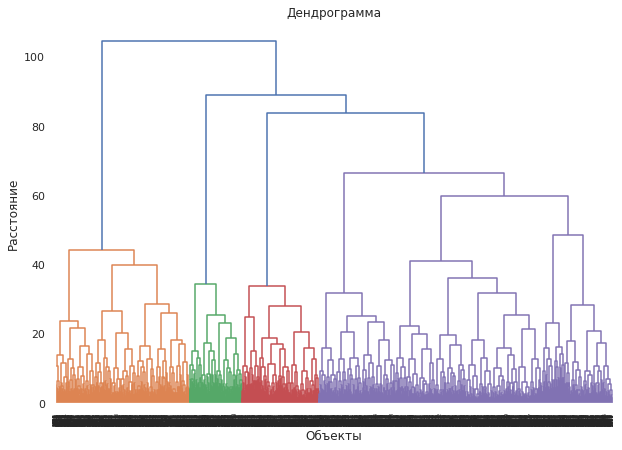

In [119]:
plt.figure(figsize = (10, 7))
dendrogram(dis)
plt.title("Дендрограмма")
plt.xlabel("Объекты")
plt.ylabel("Расстояние")
plt.show() # проектирование и вывод дендрограммы

На основании дендрограммы можно выделить 5 класстеров 

In [120]:
km = KMeans(n_clusters=5, random_state=0)
km.fit(gym_scaled) # обучение K means

gym_data["cluster"] = km.labels_ # прогнозирование кластеров 

Переходим к средним значениям признаков

In [122]:
clus_mean = gym_data.groupby("cluster").mean()
clus_mean # вывод средних значений

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,0.502970,0.959406,0.783168,0.574257,1.000000,10.889109,0.542574,29.982178,160.761016,9.954455,4.736634,1.982055,1.974789,0.027723
1,0.522078,0.862338,0.470130,0.306494,0.000000,4.787013,0.425974,29.301299,143.957664,4.475325,3.924675,1.847220,1.716369,0.267532
2,0.495050,0.000000,0.463366,0.079208,1.000000,2.352475,0.215842,28.477228,135.457501,2.198020,2.809901,1.660461,1.477324,0.443564
3,0.485737,1.000000,0.350238,0.240095,1.000000,1.948494,0.341521,28.167987,131.622204,1.856577,2.440571,1.247634,1.012983,0.514263
4,0.559666,0.976134,0.356802,0.230310,0.998807,2.669451,0.473747,30.125298,161.657905,2.459427,4.898568,2.852002,2.850161,0.068019


Распределение по полу примерно одинаковое во всех кластерах. Во втором кластере все клиенты живут или работают далеко от фитнес-центра. В первом кластере никто не оставил контактный номер. Наибольший отток наблюдается в третьем кластере, а самый низкий — в нулевом. В следующем шаге построим графики распределения для кластеров 

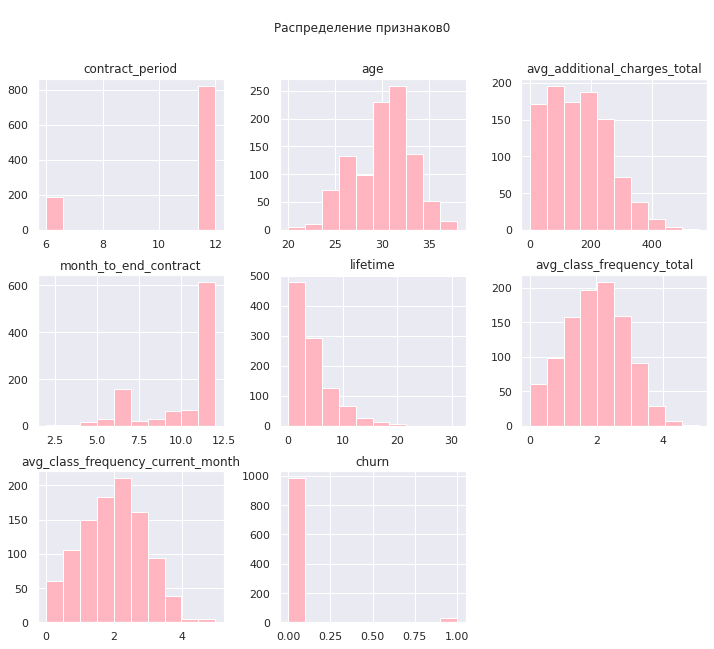

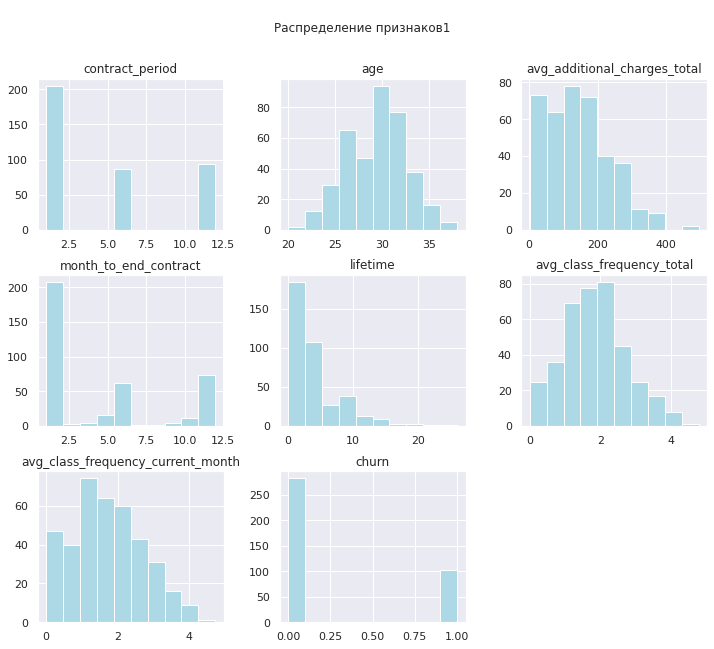

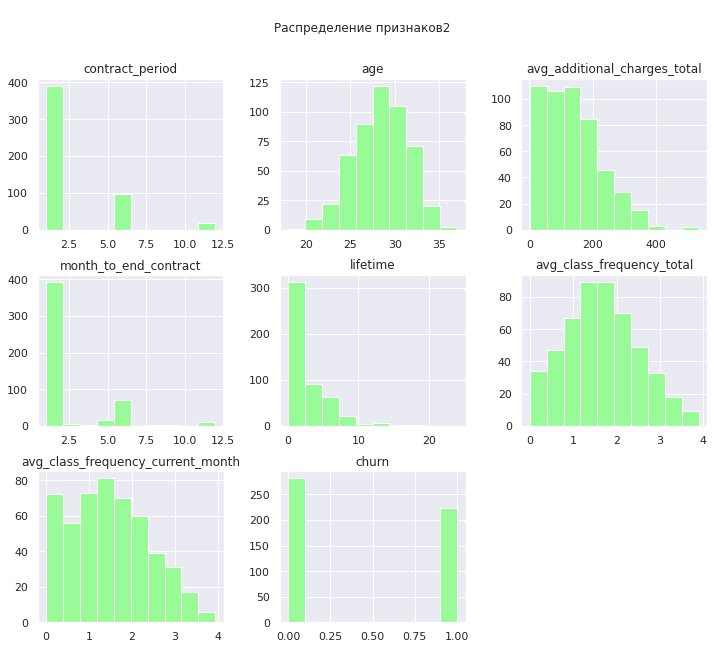

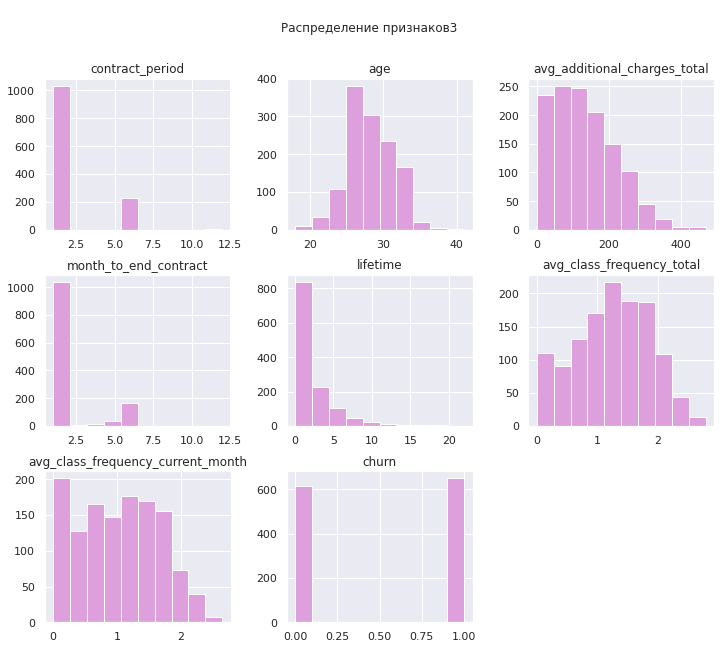

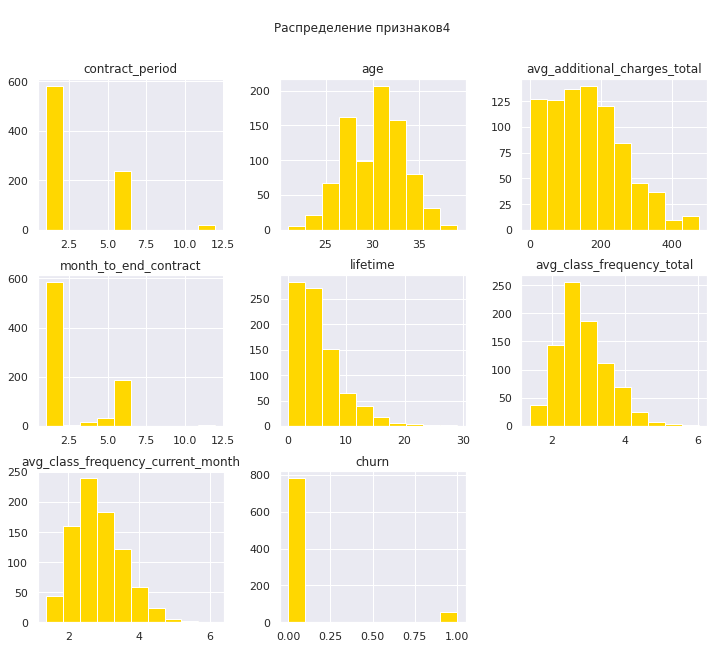

In [125]:
clus_plot = 5
colors = ['#FFB6C1', '#ADD8E6', '#98FB98', '#DDA0DD', '#FFD700']  # загрузка палитры

for cluster in range(clus_plot):
    cluster_data = gym_data[gym_data["cluster"] == cluster].drop("cluster", axis=1)  # исключение столбца
    cluster_data.hist(figsize=(12, 10), color=colors[cluster])  # устанавливаем пастельный цвет для текущего кластера
    plt.suptitle("\nРаспределение признаков{}".format(cluster), fontsize = 12)
    plt.show()  

Краткий вывод по кластерам:

1. Кластер 0:
- Живут/работают рядом, пришли по партнерской или промо-программе, все оставили телефон.
- Предпочитают длительные абонементы (12 мес.), активно посещают групповые занятия, возраст около 30 лет, высокая выручка от допуслуг, длительный лайфтам (≈5 мес.), посещают 2 раза в неделю, низкий отток.

2. Кластер 1:
- Живут/работают рядом, половина по партнерской программе, треть — по промо, у всех есть телефон.
- В основном покупают абонементы на 1 месяц, посещают групповые занятия регулярно, средний возраст около 29 лет, лайфтам ≈4 мес., посещают 2 раза в неделю, средний уровень оттока.

3. Кластер 2:
- Живут/работают далеко от центра, половина по партнерской программе, почти все с телефоном. 
- Предпочитают короткие абонементы (чаще 1 мес.), реже посещают групповые занятия, возраст около 28.5 лет, лайфтам ≈3 мес., посещают 1.5 раза в неделю, второй по уровню оттока.

4. Кластер 3:
- Живут/работают близко к центру, треть по партнерской и четверть по промо-программе, все с телефоном.
- Обычно покупают короткие абонементы (1-6 мес.), редко посещают занятия, возраст около 26-28 лет, лайфтам ≈2.5 мес., посещают реже всех и имеют самый высокий уровень оттока.

5. Кластер 4:
- Живут/работают рядом, треть по партнерской и четверть по промо-программе, все с телефоном. 
- Предпочитают абонементы на 1 или 6 месяцев, активно посещают групповые занятия (≈3 раза в неделю), возраст около 30 лет, самая высокая выручка от допуслуг, лайфтам ≈5 мес., самый низкий уровень оттока.

Посчитаем долю оттока в процентах

In [126]:
churn = gym_data.query("churn==1").groupby("cluster")["churn"].count() / gym_data.query("churn==1")["churn"].count()*100
churn

cluster
0     2.639020
1     9.707823
2    21.112158
3    61.168709
4     5.372290
Name: churn, dtype: float64

Самый высокий уровень оттока наблюдается в кластере с самыми молодыми клиентами, которые чаще приобретали абонементы на 1 месяц, реже посещали занятия и использовали дополнительные услуги. Наоборот, наиболее стабильный кластер с минимальной долей оттока — это кластер 0, где клиенты воспользовались акцией при покупке абонемента, выбрали длительный срок (12 месяцев), активно пользуются допуслугами и регулярно посещают фитнес-клуб примерно 2 раза в неделю

# Вывод 

В ходе анализа оттока клиентов фитнес-клуба была проведена предварительная обработка данных, изучены основные характеристики:
- 85% клиентов живут или работают рядом
- Половина — по партнерской программе
- 90% указали телефон
- Большинство приобретают абонементы на месяц
- Средний возраст — 29 лет
- Средняя выручка от допуслуг — 146
- Средний срок до окончания договора — 4.3 месяца
- Частота посещений — около 1.87 раз в неделю
- Доля оттока — 27%.

Анализ показал, что клиенты, ушедшие (средний возраст 27 лет), реже посещали клуб и тратили меньше на допуслуги. Основные причины ухода связаны с короткими абонементами (чаще на месяц) и отсутствием регулярных посещений. Отток сильнее у молодых клиентов и тех, кто не пользуется акциями или программами лояльности.

Модели прогнозирования (логистическая регрессия и случайный лес) показали, что логистическая регрессия лучше предсказывает отток по метрикам accuracy и precision.

Кластеризация выявила пять групп клиентов: самый стабильный — те, кто приобрели длительный абонемент (12 мес.) и стабильно посещают клуб; самый уязвимый — молодые клиенты с короткими абонементами и редкими посещениями.


# Рекомендации

1. Стимулировать приобретение длительных абонементов (12 мес.) с привлекательными условиями и включением дополнительных услуг.
2. Разработать акции для привлечения более молодых клиентов и тех, кто склонен к краткосрочным покупкам.
3. Расширить использование программ лояльности и акций для повышения удержания.
4. Анализировать периодичность акций для увеличения их эффективности в привлечении новых клиентов и снижении оттока.